# Porto Seguro Data Set EDA Notebook

### 1. Initial Setup, Configurations and Data Load

In [1]:
# pip install catboost

In [19]:
#-------------------------------------------------------------
# 1.1 Setup
#-------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import warnings
from scipy.stats import chi2_contingency

#----sileBILIRSIN
#from sklearn.ensemble import RandomForestClassifier
#import lightgbm as lgb
#from scipy.stats import spearmanr
#from sklearn.metrics import roc_auc_score
#import xgboost as xgb
#from sklearn.model_selection import StratifiedKFold
#from catboost import CatBoostClassifier
#from sklearn.preprocessing import LabelEncoder
#from sklearn.model_selection import train_test_split

In [3]:
#-------------------------------------------------------------
# 1.2 set config
#-------------------------------------------------------------
# Pandas
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', 10)  
pd.set_option('display.max_colwidth', 15) 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Python
# pretty print
pp = pprint.PrettyPrinter(indent=4)

# Warnings handle
warnings.filterwarnings('ignore')

In [4]:
#-------------------------------------------------------------
# 1.3 Load Dataset
#-------------------------------------------------------------
df=pd.read_csv("train.csv")

print("Shape of dataset:", df.shape)
pd.set_option('display.max_columns', 59)  
display(df.head(3))

Shape of dataset: (595212, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0


In [5]:
#-------------------------------------------------------------
# 1.4 Basic Info
# ------------------------------------------------------------
print(df.info())
print("\nSummary statistics (numeric features):")
display(df.describe().T)  #display(df.describe().T.head(10))

pd.set_option('display.max_columns', 10)  
pd.set_option('display.max_colwidth', 15) 

# Feature type counts (binary, categorical, continuous)
#-------------------------------------------------------------
binary_cols = [col for col in df.columns if col.endswith('_bin')]
categorical_cols = [col for col in df.columns if col.endswith('_cat')]
continuous_cols = [col for col in df.columns if col not in binary_cols + categorical_cols + ['id', 'target']]

print(f"Binary features: {len(binary_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Continuous features: {len(continuous_cols)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

,count,mean,std,min,25%,50%,75%,max
id,595212.0,743803.558435,429367.820429,7.000000,371991.500000,743547.500000,1.115549e+06,1.488027e+06
target,595212.0,0.036448,0.187401,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000e+00,7.000000e+00
ps_ind_02_cat,595212.0,1.358943,0.664594,-1.000000,1.000000,1.000000,2.000000e+00,4.000000e+00
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000e+00,1.100000e+01
ps_ind_04_cat,595212.0,0.416794,0.493311,-1.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_05_cat,595212.0,0.405188,1.350642,-1.000000,0.000000,0.000000,0.000000e+00,6.000000e+00
ps_ind_06_bin,595212.0,0.393742,0.488579,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_07_bin,595212.0,0.257033,0.436998,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_08_bin,595212.0,0.163921,0.370205,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


Binary features: 17
Categorical features: 14
Continuous features: 26


### Summary

In the train and test data, features that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix bin to indicate binary features and cat to indicate categorical features. Features without these designations are either continuous or ordinal.

* target column: 1="claim was filed"  0= "not insurance claim" filed for that policy holder.
* ind is related to individual or driver
* reg is related to region
* car is related to car itself
* calc is an calculated feature
* -1 values indicate that the feature was missing

### 2. Target Distribution


Target Distribution (%):
 target
0    96.355248
1     3.644752
Name: proportion, dtype: float64


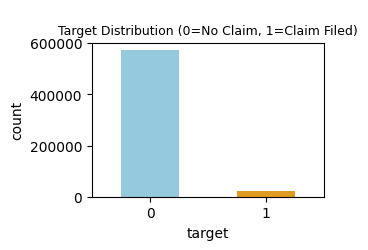

In [6]:
#-------------------------------------------------------------
# 2.1 Target Distribution Analysis
# ------------------------------------------------------------
target_counts=df['target'].value_counts(normalize=True) * 100
print("\nTarget Distribution (%):\n", target_counts)

plt.figure(figsize=(3,2))
sns.countplot(x='target', data=df, width=0.5,   palette=['skyblue', 'orange'])
plt.title("\nTarget Distribution (0=No Claim, 1=Claim Filed)", fontsize=9)
plt.show()


### 3. Missing Values Check


Missing Values Overview (-1 treated as missing):


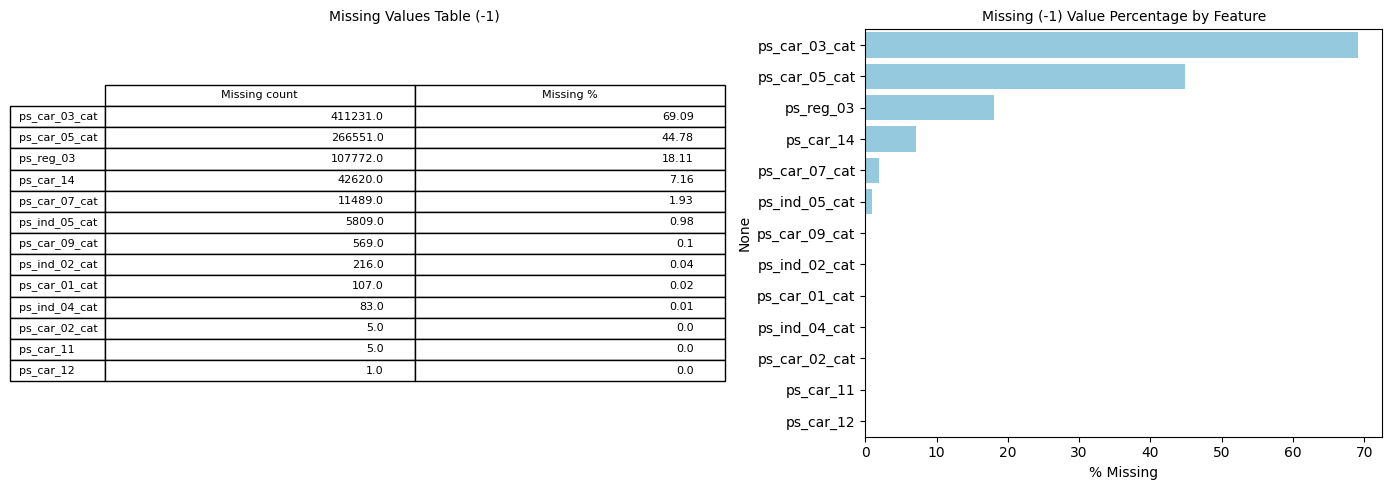

In [7]:
#-------------------------------------------------------------
# 3.1 Missing Values (-1 treated as missing)
#-------------------------------------------------------------
missing = (df == -1).sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_prct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing count": missing, "Missing %": missing_prct})

print("\nMissing Values Overview (-1 treated as missing):")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# TABLO (ax[0])
ax[0].axis('off')
tbl = ax[0].table(
    cellText=missing_df.round(2).values,
    colLabels=missing_df.columns,
    rowLabels=missing_df.index,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.2)
ax[0].set_title("Missing Values Table (-1)", fontsize=10)

# GRAFİK (ax[1])
sns.barplot(x=missing_prct, y=missing_prct.index, ax=ax[1], color='skyblue')
ax[1].set_title("Missing (-1) Value Percentage by Feature", fontsize=10)
ax[1].set_xlabel("% Missing")

plt.tight_layout()
plt.show()


### 4. Feature Analysis

In [8]:
#------------------------------------------------------------
# 4.1 Feature type counts (binary, categorical, continuous)
#------------------------------------------------------------
binary_cols = [col for col in df.columns if col.endswith('_bin')]
categorical_cols = [col for col in df.columns if col.endswith('_cat')]
continuous_cols = [col for col in df.columns if col not in binary_cols + categorical_cols + ['id', 'target']]

print("=" * 50)
print(f"Binary features: {len(binary_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Continuous features: {len(continuous_cols)}")


Binary features: 17
Categorical features: 14
Continuous features: 26



Distribution of Binary Features:
       Feature  Zeros   Ones  Ratio_1s    Balance
 ps_ind_16_bin 201882 393330  0.660823   Balanced
ps_calc_16_bin 221514 373698  0.627840   Balanced
ps_calc_17_bin 265356 329856  0.554182   Balanced
 ps_ind_06_bin 360852 234360  0.393742   Balanced
ps_calc_19_bin 387469 207743  0.349024   Balanced
ps_calc_18_bin 424278 170934  0.287182 Imbalanced
 ps_ind_07_bin 442223 152989  0.257033 Imbalanced
 ps_ind_09_bin 484917 110295  0.185304 Imbalanced
 ps_ind_08_bin 497644  97568  0.163921 Imbalanced
 ps_ind_18_bin 503879  91333  0.153446 Imbalanced
ps_calc_20_bin 503955  91257  0.153318 Imbalanced
ps_calc_15_bin 522342  72870  0.122427 Imbalanced
 ps_ind_17_bin 523143  72069  0.121081 Imbalanced
 ps_ind_12_bin 589594   5618  0.009439 Imbalanced
 ps_ind_11_bin 594205   1007  0.001692 Imbalanced
 ps_ind_13_bin 594648    564  0.000948 Imbalanced
 ps_ind_10_bin 594990    222  0.000373 Imbalanced


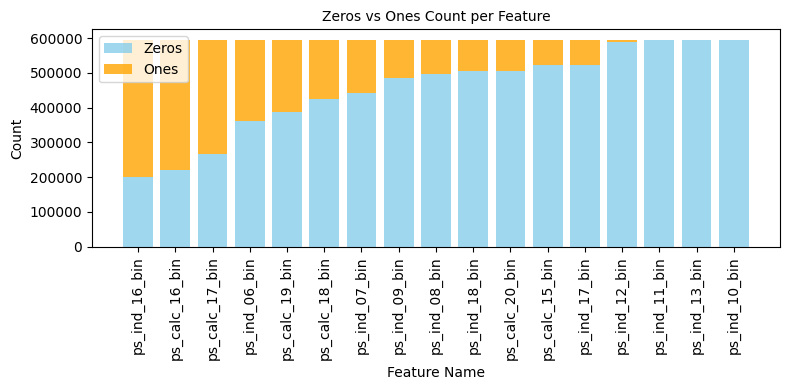

In [9]:
#------------------------------------------------------------
# 4.2 Binary Feature Analysis
#------------------------------------------------------------
bin_distribution = pd.DataFrame({
    'Feature': binary_cols,
    'Zeros': [df[col].value_counts().get(0, 0) for col in binary_cols],
    'Ones': [df[col].value_counts().get(1, 0) for col in binary_cols],
    'Ratio_1s': [df[col].mean() for col in binary_cols]
})

bin_distribution['Balance'] = bin_distribution['Ratio_1s'].apply(
    lambda x: 'Balanced' if 0.3 <= x <= 0.7 else 'Imbalanced'
)

bin_distribution = bin_distribution.sort_values('Ratio_1s', ascending=False)

print("\nDistribution of Binary Features:")
print(bin_distribution.to_string(index=False))


plt.figure(figsize=(8, 4))

zeros = bin_distribution['Zeros']
ones = bin_distribution['Ones']
features = bin_distribution['Feature']

plt.bar(features, zeros, label='Zeros', color='skyblue', alpha=0.8)
plt.bar(features, ones, bottom=zeros, label='Ones', color='orange',alpha=0.8)

plt.xticks(rotation=90)
plt.title("Zeros vs Ones Count per Feature",  fontsize=10)
plt.xlabel("Feature Name")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()



----------------------------------------------------------------------
  Categorical Feature Analysis
----------------------------------------------------------------------

Categorical Feature Statistics:
      Feature  Cardinality  Missing_Pct  Most_Common  Most_Common_Freq
ps_car_11_cat          104     0.000000          104         14.294571
ps_car_06_cat           18     0.000000           11         22.097505
ps_car_01_cat           13     0.017977           11         34.873793
ps_car_04_cat           10     0.000000            0         83.429266
ps_ind_05_cat            8     0.975955            0         88.709401
ps_car_09_cat            6     0.095596            2         59.387580
ps_ind_02_cat            5     0.036290            1         72.555493
ps_car_03_cat            3    69.089837           -1         69.089837
ps_ind_04_cat            3     0.013945            0         58.292676
ps_car_02_cat            3     0.000840            1         82.993958
ps_car_07_ca

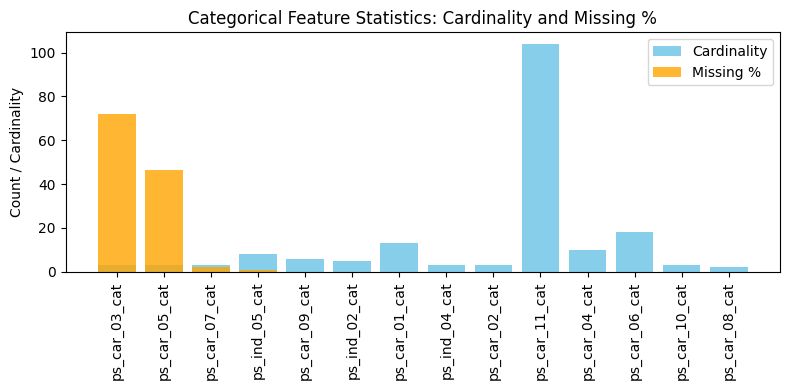


Classification by Cardinality:
Cardinality_Type
Low (≤10)         11
Medium (11-50)     2
High (>50)         1
Name: count, dtype: int64


In [10]:
#-------------------------------------------------------------
# 4.3 Categorical Feature Analysis
# ------------------------------------------------------------
print("\n" + "-"*70)
print("  Categorical Feature Analysis")
print("-"*70)

# Cardinality and statistics
cat_stats = pd.DataFrame({
    'Feature': categorical_cols,
    'Cardinality': [df[col].nunique() for col in categorical_cols],
    'Missing_Pct': [(df[col] == -1).sum() / len(df) * 100 for col in categorical_cols],
    'Most_Common': [df[col].mode()[0] if len(df[col].mode()) > 0 else None for col in categorical_cols],
    'Most_Common_Freq': [df[col].value_counts().iloc[0] / len(df) * 100 for col in categorical_cols]
})

# Sort by cardinality descending
cat_stats = cat_stats.sort_values('Cardinality', ascending=False)

print("\nCategorical Feature Statistics:")
print(cat_stats.to_string(index=False))

# Sort features by Missing_Pct descending for readability
cat_stats_sorted = cat_stats.sort_values('Missing_Pct', ascending=False)
features = cat_stats_sorted['Feature']
missing_pct = cat_stats_sorted['Missing_Pct']
cardinality = cat_stats_sorted['Cardinality']

plt.figure(figsize=(8,4))

# Base bar: Cardinality
bars = plt.bar(features, cardinality, color='skyblue', label='Cardinality')

# Overlay missing % as red transparent bar
plt.bar(features, missing_pct * max(cardinality)/100, color='orange', alpha=0.8, label='Missing %')

plt.xticks(rotation=90)
plt.ylabel("Count / Cardinality")
plt.title("Categorical Feature Statistics: Cardinality and Missing %")
plt.legend()
plt.tight_layout()
plt.show()
# Classify by cardinality
cat_stats['Cardinality_Type'] = cat_stats['Cardinality'].apply(
    lambda x: 'Low (≤10)' if x <= 10 else ('Medium (11-50)' if x <= 50 else 'High (>50)')
)

print("\nClassification by Cardinality:")
print(cat_stats['Cardinality_Type'].value_counts())


In [11]:
#--------------------------------------------
# 4.4 Numerical Feature Analysis
# -------------------------------------------
print("\n" + "-"*70)
print("  Numerical Feature Analysis")
print("-"*70)

# Base descriptive statistics
num_stats = df[continuous_cols].describe().T

# Additional metrics
num_stats["cardinality"] = df[continuous_cols].nunique()
num_stats["skewness"] = df[continuous_cols].skew()
num_stats["kurtosis"] = df[continuous_cols].kurtosis()
num_stats["missing_pct"] = (df[continuous_cols] == -1).sum() / len(df) * 100

# Final clean output
print("\nDescriptive Statistics of Numerical Features:")
print(
    num_stats[
        ["cardinality", "mean", "std", "min", "max", "skewness", "kurtosis", "missing_pct"]
    ].round(3)
)



----------------------------------------------------------------------
  Numerical Feature Analysis
----------------------------------------------------------------------

Descriptive Statistics of Numerical Features:
            cardinality   mean    std    min     max  skewness  kurtosis  missing_pct
ps_ind_01             8  1.900  1.984  0.000   7.000     0.932    -0.219        0.000
ps_ind_03            12  4.423  2.700  0.000  11.000     0.464    -0.650        0.000
ps_ind_14             5  0.012  0.128  0.000   4.000    12.208   180.698        0.000
ps_ind_15            14  7.300  3.546  0.000  13.000    -0.286    -0.736        0.000
ps_reg_01            10  0.611  0.288  0.000   0.900    -0.639    -0.887        0.000
ps_reg_02            19  0.439  0.404  0.000   1.800     1.281     1.124        0.000
ps_reg_03          5013  0.551  0.794 -1.000   4.038    -1.013     0.086       18.106
ps_car_11             5  2.346  0.833 -1.000   3.000    -1.173     0.668        0.001
ps_car_

In [12]:
#-------------------------------------------------------------
# 4.5 Numerical Features
# Ordinal vs Real Continuous split (cardinality-based)
#-------------------------------------------------------------
ordinal_columns = num_stats[num_stats["cardinality"] <= 30].index.tolist()
real_continuous_columns = num_stats[num_stats["cardinality"] > 30].index.tolist()

print("\n--> ORDINAL Columns:")
print(ordinal_columns)

print("\n--> REAL CONTINUOUS Columns:")
print(real_continuous_columns)



--> ORDINAL Columns:
['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_car_11', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']

--> REAL CONTINUOUS Columns:
['ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_14']



----------------------------------------------------------------------
  Ordinal Feature Analysis
----------------------------------------------------------------------

Ordinal Features Statistics (Skew, Kurtosis, Missing, Cardinality):
       Feature  Skewness  Kurtosis  Missing_Pct  Cardinality
2    ps_ind_14    12.208   180.698        0.000            5
6    ps_car_11    -1.173     0.668        0.001            5
11  ps_calc_04     0.044    -0.404        0.000            6
12  ps_calc_05     0.329    -0.221        0.000            7
0    ps_ind_01     0.932    -0.219        0.000            8
16  ps_calc_09     0.262    -0.224        0.000            8
8   ps_calc_01    -0.001    -1.225        0.000           10
9   ps_calc_02     0.001    -1.220        0.000           10
10  ps_calc_03     0.001    -1.224        0.000           10
14  ps_calc_07     0.233    -0.175        0.000           10
4    ps_reg_01    -0.639    -0.887        0.000           10
13  ps_calc_06    -0.408    -

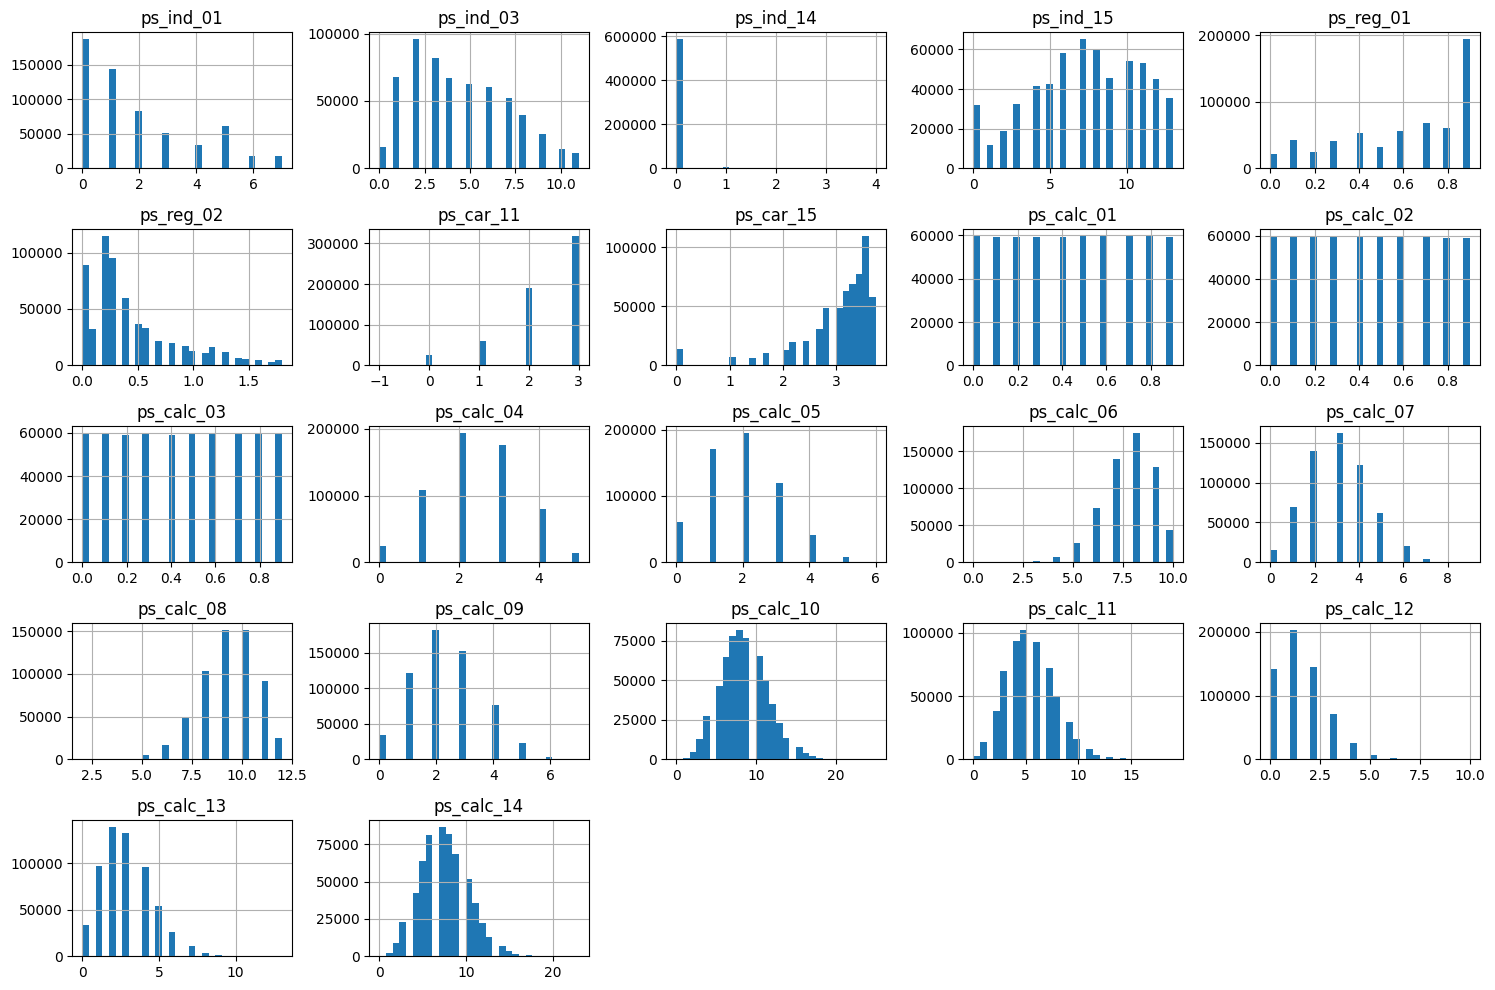

In [13]:
#-----------------------------------------------------------------
# 4.6 Ordinal Feature Analysis
# Note: Rare classes are only reported here.
# Actual collapsing is performed later with a stricter threshold.
# -----------------------------------------------------------------
print("\n" + "-"*70)
print("  Ordinal Feature Analysis")
print("-"*70)

# 1) Calculating Skewness & kurtosis
ordinal_stats = pd.DataFrame({
    'Feature': ordinal_columns, # ordinal_candidates,
    'Skewness': [df[col].skew() for col in ordinal_columns],
    'Kurtosis': [df[col].kurtosis() for col in ordinal_columns],
    'Missing_Pct': [(df[col] == -1).sum() / len(df) * 100 for col in ordinal_columns],
    'Cardinality': [df[col].nunique() for col in ordinal_columns]
}).sort_values('Cardinality')

print("\nOrdinal Features Statistics (Skew, Kurtosis, Missing, Cardinality):")
print(ordinal_stats.round(3))

# 2) Checking Rare Classes
rare_threshold = 0.05  # classes less than %5
for col in ordinal_columns:
    value_counts = df[col].value_counts(normalize=True)
    rare_classes = value_counts[value_counts < rare_threshold]
    if len(rare_classes) > 0:
        print(f"\n--> Rare classes in {col}:")
        print(rare_classes)

# Histograms for continuous features
df[ordinal_columns].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()



Real Continuous Features Statistics (Skew, Kurtosis, Missing):
     Feature   Mean    Std    Min    Max  Skewness  Kurtosis  Missing_Pct
2  ps_car_13  0.813  0.225  0.251  3.721     1.701     5.422        0.000
1  ps_car_12  0.380  0.058 -1.000  1.265     1.067     5.495        0.000
0  ps_reg_03  0.551  0.794 -1.000  4.038    -1.013     0.086       18.106
3  ps_car_14  0.276  0.357 -1.000  0.636    -3.234     8.690        7.160


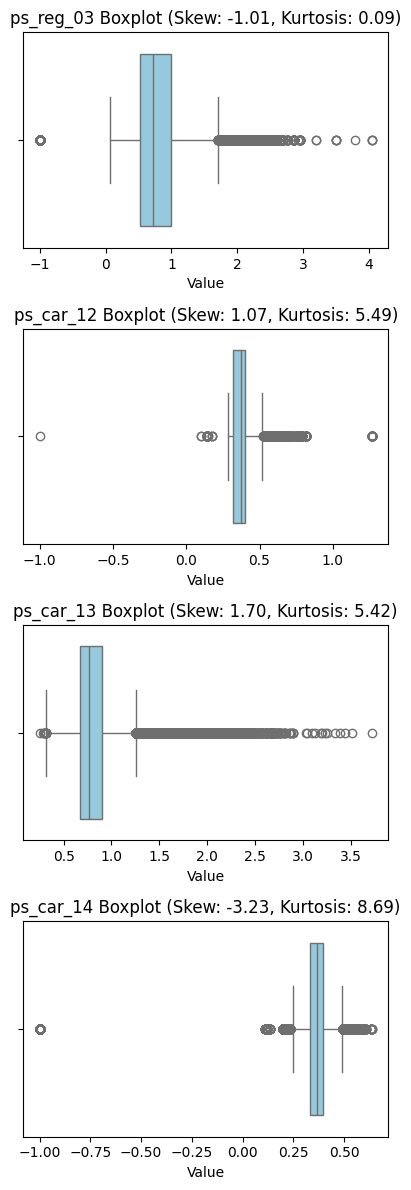

→ ps_car_14 is highly skewed (-3.23)


In [14]:
#-------------------------------------------------------------
# 4.7 Real Continuous Features Statistics 
#-------------------------------------------------------------
# 1) Descriptive statistics
real_cont_stats = pd.DataFrame({
    'Feature': real_continuous_columns,
    'Mean': [df[col].mean() for col in real_continuous_columns],
    'Std': [df[col].std() for col in real_continuous_columns],
    'Min': [df[col].min() for col in real_continuous_columns],
    'Max': [df[col].max() for col in real_continuous_columns],
    'Skewness': [df[col].skew() for col in real_continuous_columns],
    'Kurtosis': [df[col].kurtosis() for col in real_continuous_columns],
    'Missing_Pct': [(df[col]==-1).mean()*100 for col in real_continuous_columns]
}).sort_values('Skewness', ascending=False)

print("\nReal Continuous Features Statistics (Skew, Kurtosis, Missing):")
print(real_cont_stats.round(3))

# 2) Outlier check (boxplot)
fig, axes = plt.subplots(len(real_continuous_columns), 1, figsize=(4, 3 * len(real_continuous_columns)))
if len(real_continuous_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, real_continuous_columns):
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(f'{col} Boxplot (Skew: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f})', fontsize=12)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

# 3) Skewness transformation suggession
for col in real_continuous_columns:
    skew_val = df[col].skew()
    if skew_val > 2 or skew_val < -2:
        print(f'→ {col} is highly skewed ({skew_val:.2f})')


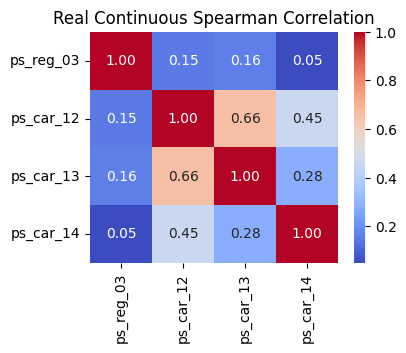

High correlated real continuous pairs: []


In [15]:
#-------------------------------------------------------------
# 4.8 Correlation Check for Real Continuous Features
#-------------------------------------------------------------
corr_real = df[real_continuous_columns].corr(method='spearman')

plt.figure(figsize=(4,3))
sns.heatmap(corr_real, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Real Continuous Spearman Correlation")
plt.show()

threshold = 0.85
high_corr_real = [
    (corr_real.columns[i], corr_real.columns[j], corr_real.iloc[i,j])
    for i in range(len(corr_real.columns))
    for j in range(i)
    if abs(corr_real.iloc[i,j]) > threshold
]

print("High correlated real continuous pairs:", high_corr_real)

#The real continuous features show no high multicollinearity.
#The highest correlation observed is 0.66, which is below the threshold (0.85).
#Therefore, none of the continuous features should be dropped at this stage.
#All four variables contain unique signal and can be safely kept for modeling.

High correlation pairs (ordinal):


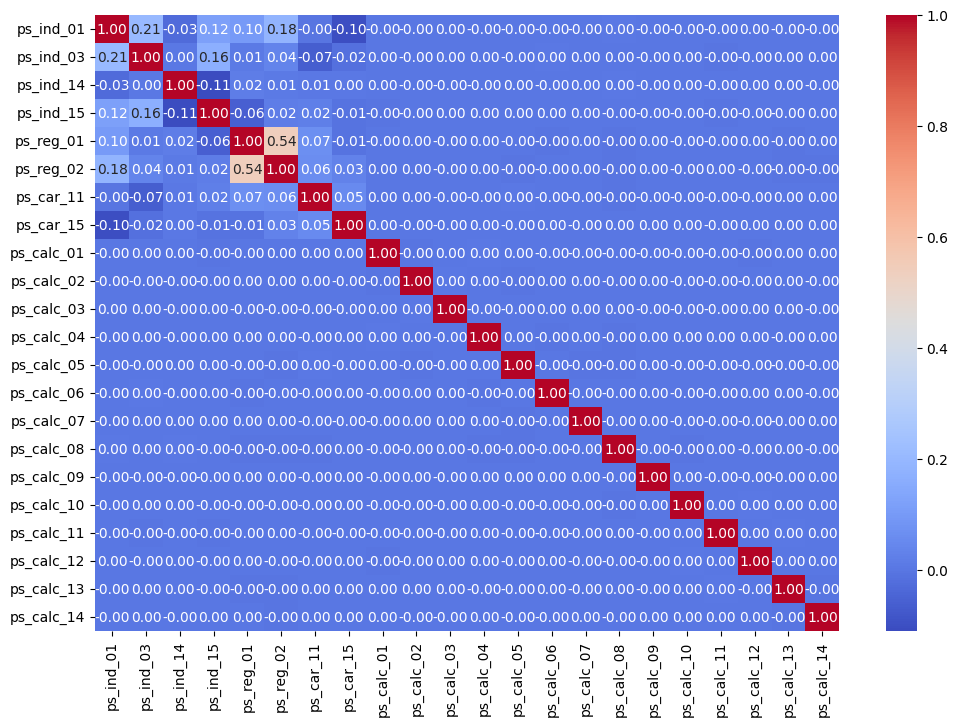

In [16]:
# -----------------------------------------------------------
# 4.9 Correlation Check for Ordinal Features
#------------------------------------------------------------
corr_matrix_ord = df[ordinal_columns].corr(method='spearman')

threshold = 0.85
high_corr_pairs_ord = []

for i in range(len(corr_matrix_ord.columns)):
    for j in range(i):
        if abs(corr_matrix_ord.iloc[i, j]) > threshold:
            high_corr_pairs_ord.append((
                corr_matrix_ord.columns[i],
                corr_matrix_ord.columns[j],
                corr_matrix_ord.iloc[i, j]
            ))

print("High correlation pairs (ordinal):")
for a, b, c in high_corr_pairs_ord:
    print(f"{a} <> {b} | corr = {c:.3f}")

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix_ord, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [20]:
# --------------------------------------------------------------
# 4.10 Categorical Features – High Association Check (Cramér's V)
# This section computes pairwise associations between categorical features using Cramér's V.
# High association (V > 0.8) indicates potential redundancy.
# No pairs above the threshold implies that categorical features provide largely independent information.
# --------------------------------------------------------------
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k-1, r-1))

high_cramer_pairs = []

for i in range(len(categorical_cols)):
    for j in range(i):
        v = cramers_v(df[categorical_cols[i]], df[categorical_cols[j]])
        if v > 0.8:
            high_cramer_pairs.append((categorical_cols[i], categorical_cols[j], v))

print("High association categorical pairs:")
for a,b,v in high_cramer_pairs:
    print(f"{a} <> {b} | V={v:.3f}")


High association categorical pairs:
